In [53]:
!pip install yfinance -q

In [54]:
import yfinance as yf
import pandas as pd

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [55]:
df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

/tmp/ipykernel_3787/2170626248.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [56]:


# Fix MultiIndex columns
df.columns = [col[0].lower() if isinstance(col, tuple) else col.lower() for col in df.columns]

df.head()

,close,high,low,open,volume
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


In [57]:

print("Shape:", df.shape)
df.info()

Shape: (1006, 5)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   1006 non-null   float64
 1   high    1006 non-null   float64
 2   low     1006 non-null   float64
 3   open    1006 non-null   float64
 4   volume  1006 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.2 KB


In [58]:
df.describe()

,close,high,low,open,volume
count,1006.000000,1006.000000,1006.000000,1006.000000,1.006000e+03
mean,137.957992,139.439050,136.328682,137.827952,9.895373e+07
std,33.357829,33.477922,33.218686,33.351564,5.439610e+07
min,54.213608,55.211524,51.372088,55.110042,2.404830e+07
25%,120.397026,121.638011,118.864119,120.502561,6.407675e+07
50%,142.816368,144.390231,141.154853,142.666125,8.467540e+07
75%,163.195053,165.471080,161.941445,163.462842,1.155069e+08
max,196.073090,197.567559,194.974504,195.984019,4.265100e+08


In [59]:
df.isnull().sum()

,0
close,0
high,0
low,0
open,0
volume,0


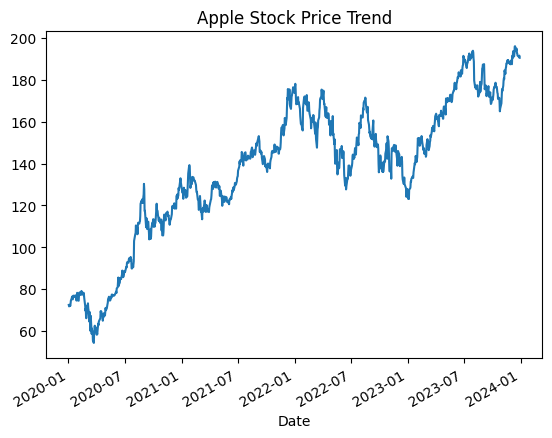

In [60]:
plt.figure()
df['close'].plot(title="Apple Stock Price Trend")
plt.show()

In [61]:
# Daily return (percentage change)
df['return_1d'] = df['close'].pct_change()

df.head()

,close,high,low,open,volume,return_1d
Date,,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400,NaN
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800,-0.009722
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200,0.007968
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000,-0.004703
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200,0.016086


In [62]:
# Log return
df['log_return'] = np.log(df['close'] / df['close'].shift(1))

df.head()

,close,high,low,open,volume,return_1d,log_return
Date,,,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400,NaN,NaN
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800,-0.009722,-0.009770
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200,0.007968,0.007937
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000,-0.004703,-0.004714
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200,0.016086,0.015958


In [64]:
# 7-day moving average
df['ma_7'] = df['close'].rolling(window=7).mean()

df.head(10)

,close,high,low,open,volume,return_1d,log_return,ma_7
Date,,,,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400,NaN,NaN,NaN
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800,-0.009722,-0.009770,NaN
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200,0.007968,0.007937,NaN
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000,-0.004703,-0.004714,NaN
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200,0.016086,0.015958,NaN
2020-01-09,74.637497,74.830337,73.810684,74.061375,170108400,0.021241,0.021018,NaN
2020-01-10,74.806244,75.370316,74.304855,74.871333,140644800,0.002261,0.002258,72.974573
2020-01-13,76.404404,76.430923,75.003882,75.122003,121532000,0.021364,0.021139,73.546557
2020-01-14,75.372696,76.551452,75.249763,76.341737,161954400,-0.013503,-0.013595,74.071708


In [66]:
# Volatility (risk measurement)
df['volatility'] = df['close'].rolling(window=7).std()

df.head(10)

,close,high,low,open,volume,return_1d,log_return,ma_7,volatility
Date,,,,,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400,NaN,NaN,NaN,NaN
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800,-0.009722,-0.009770,NaN,NaN
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200,0.007968,0.007937,NaN,NaN
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000,-0.004703,-0.004714,NaN,NaN
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200,0.016086,0.015958,NaN,NaN
2020-01-09,74.637497,74.830337,73.810684,74.061375,170108400,0.021241,0.021018,NaN,NaN
2020-01-10,74.806244,75.370316,74.304855,74.871333,140644800,0.002261,0.002258,72.974573,1.270808
2020-01-13,76.404404,76.430923,75.003882,75.122003,121532000,0.021364,0.021139,73.546557,1.771711
2020-01-14,75.372696,76.551452,75.249763,76.341737,161954400,-0.013503,-0.013595,74.071708,1.674110


In [67]:
df.tail()

,close,high,low,open,volume,return_1d,log_return,ma_7,volatility
Date,,,,,,,,,
2023-12-22,191.609467,193.400854,190.985939,193.173208,37149600,-0.005547,-0.005563,193.931059,1.649367
2023-12-26,191.065140,191.896500,190.847401,191.619380,28919300,-0.002841,-0.002845,193.215637,1.651508
2023-12-27,191.164078,191.510485,189.125261,190.510875,48087700,0.000518,0.000518,192.590698,1.440112
2023-12-28,191.589676,192.658574,191.183888,192.143916,34049900,0.002226,0.002224,192.264093,1.356902
2023-12-29,190.550476,192.401245,189.758698,191.906385,42672100,-0.005424,-0.005439,191.640573,0.840061


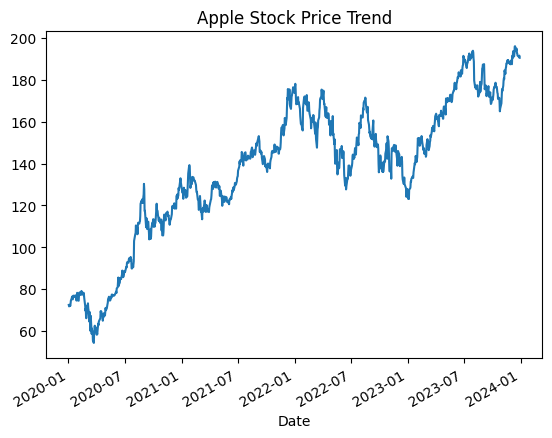

In [68]:
plt.figure()
df['close'].plot(title="Apple Stock Price Trend")
plt.show()

<Figure size 640x480 with 0 Axes>

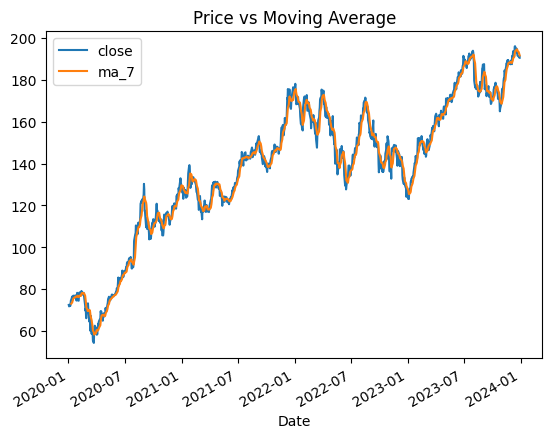

In [69]:
plt.figure()
df[['close', 'ma_7']].plot(title="Price vs Moving Average")
plt.show()

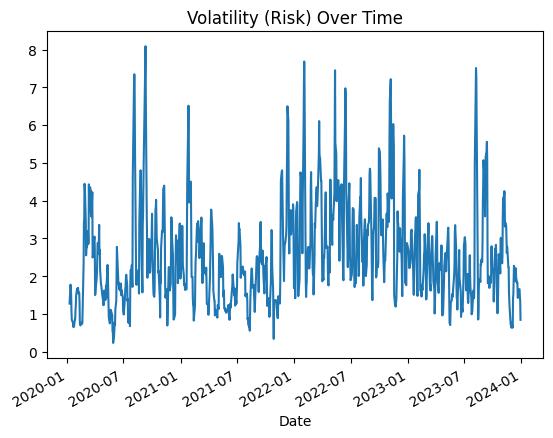

In [70]:
plt.figure()
df['volatility'].plot(title="Volatility (Risk) Over Time")
plt.show()

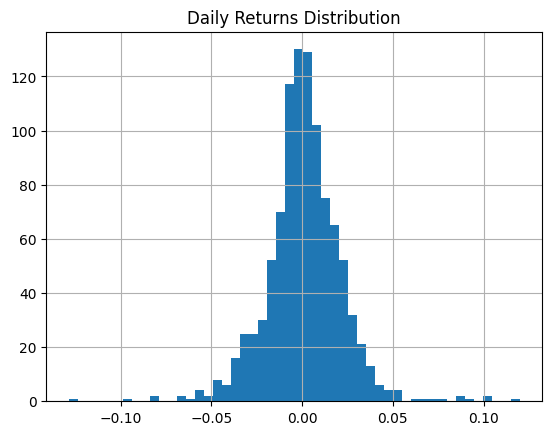

In [71]:
plt.figure()
df['return_1d'].hist(bins=50)
plt.title("Daily Returns Distribution")
plt.show()

In [72]:
df[['close', 'ma_7', 'volatility']].corr()

,close,ma_7,volatility
close,1.000000,0.994824,0.133101
ma_7,0.994824,1.000000,0.138092
volatility,0.133101,0.138092,1.000000


In [73]:

df.to_csv("final_stock_data.csv", index=False)

## Insights

- Apple stock shows an overall upward trend after 2020
- The 7-day moving average smooths short-term fluctuations
- Volatility increases during uncertain periods
- Daily returns are centered around zero